In [2]:
# ============================================
# 1. LIBRARY IMPORTS
# ============================================

# --- Data manipulation and analysis ---
import pandas as pd              # Tabular data structures
import numpy as np               # Numerical computing

# --- Data visualization ---
import matplotlib.pyplot as plt  # Low-level plotting
import seaborn as sns            # Statistical data visualization

# ============================================
# 2. GLOBAL PLOT CONFIGURATION
# ============================================

# Set the visual style for all plots
plt.style.use('seaborn-v0_8-darkgrid')

# Set the color palette
sns.set_palette("husl")

# Set default figure size
plt.rcParams['figure.figsize'] = (12, 6)

# Set default font size
plt.rcParams['font.size'] = 11

In [5]:
# ============================================
# 3. LOADING THE SYNTHETIC DATASET
# ============================================

import os
import sys

def load_dataset(data_dir: str = '../data/raw') -> dict:
    """
    Load all CSV files from the synthetic dataset.
    
    Args:
        data_dir (str): Path to the directory containing CSV files.
    
    Returns:
        dict: Dictionary containing the loaded DataFrames.
    """
    # Define file paths
    file_paths = {
        'datanodes': os.path.join(data_dir, 'datanodes.csv'),
        'blocks': os.path.join(data_dir, 'blocks.csv'),
        'jobs': os.path.join(data_dir, 'jobs.csv'),
        'access_patterns': os.path.join(data_dir, 'access_patterns.csv'),
        'placements': os.path.join(data_dir, 'placements.csv')
    }
    
    # Load each CSV file into a DataFrame
    dataset = {}
    for name, path in file_paths.items():
        dataset[name] = pd.read_csv(path)
    
    return dataset


# Load the dataset
dataset = load_dataset('../data/raw')

# Extract each DataFrame for easier access
datanodes = dataset['datanodes']              # 50 storage servers
blocks = dataset['blocks']                    # 1000 data blocks
jobs = dataset['jobs']                        # 500 processing tasks
access_patterns = dataset['access_patterns']  # Job → Block relationships
placements = dataset['placements']            # Block → DataNode placement

# Display a summary of dimensions
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"DataNodes        : {datanodes.shape[0]:>5} rows, {datanodes.shape[1]:>3} columns")
print(f"Blocks           : {blocks.shape[0]:>5} rows, {blocks.shape[1]:>3} columns")
print(f"Jobs             : {jobs.shape[0]:>5} rows, {jobs.shape[1]:>3} columns")
print(f"Access Patterns  : {access_patterns.shape[0]:>5} rows, {access_patterns.shape[1]:>3} columns")
print(f"Placements       : {placements.shape[0]:>5} rows, {placements.shape[1]:>3} columns")
print("=" * 50)

DATASET SUMMARY
DataNodes        :    50 rows,   9 columns
Blocks           :  1000 rows,   8 columns
Jobs             :   500 rows,  10 columns
Access Patterns  :  4909 rows,   4 columns
Placements       :  2981 rows,   4 columns


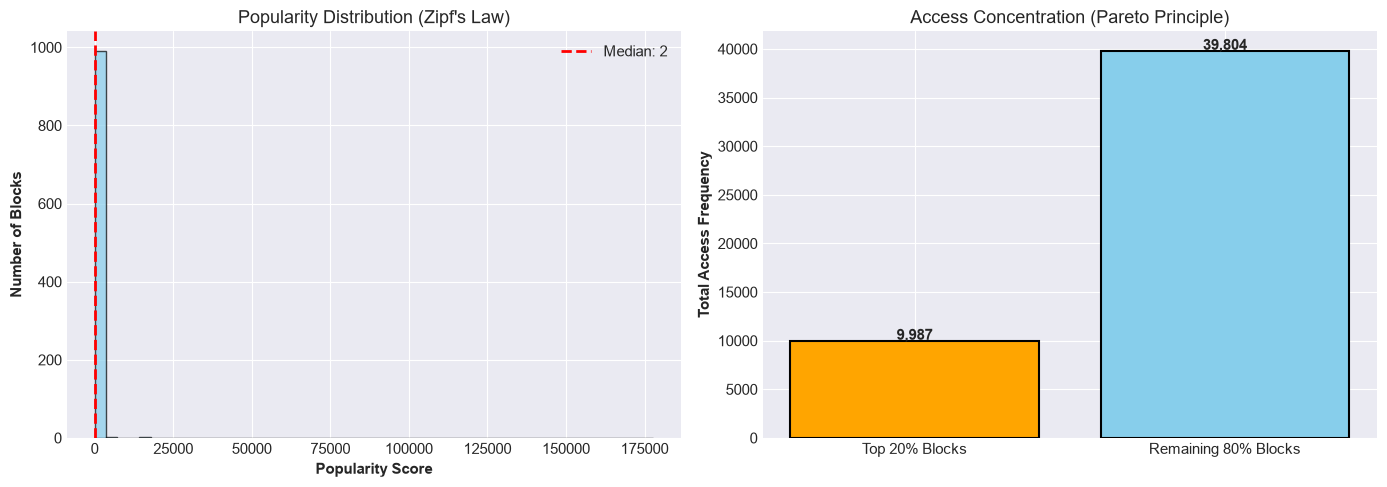

Pareto Analysis:
  - 200 blocks (20%) account for 20.1% of accesses
  - 800 blocks (80%) share 79.9% of accesses


In [6]:
# ============================================
# 4. BLOCK POPULARITY ANALYSIS
# ============================================

def plot_popularity_distribution(blocks_df: pd.DataFrame) -> None:
    """
    Visualize the distribution of block popularity.
    
    This function creates two plots:
    1. A histogram showing the popularity distribution (Zipf's law)
    2. A bar chart illustrating the Pareto principle (80/20 rule)
    
    Args:
        blocks_df (pd.DataFrame): DataFrame containing block data.
    """
    # Create a figure with two side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Subplot 1: Popularity histogram ---
    axes[0].hist(
        blocks_df['popularity_score'],
        bins=50,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )
    axes[0].set_xlabel('Popularity Score', fontweight='bold')
    axes[0].set_ylabel('Number of Blocks', fontweight='bold')
    axes[0].set_title('Popularity Distribution (Zipf\'s Law)', fontsize=13)
    
    # Add median line as reference
    median_value = blocks_df['popularity_score'].median()
    axes[0].axvline(median_value, color='red', linestyle='--', linewidth=2, 
                    label=f'Median: {median_value:.0f}')
    axes[0].legend()
    
    # --- Subplot 2: Pareto principle ---
    # Identify the top 20% most popular blocks
    top_20_count = int(len(blocks_df) * 0.2)
    top_20_blocks = blocks_df.nlargest(top_20_count, 'popularity_score')
    
    # Calculate total access frequencies
    total_accesses = blocks_df['access_frequency'].sum()
    top_20_accesses = top_20_blocks['access_frequency'].sum()
    
    # Create bar chart
    categories = ['Top 20% Blocks', 'Remaining 80% Blocks']
    values = [top_20_accesses, total_accesses - top_20_accesses]
    colors = ['orange', 'skyblue']
    
    bars = axes[1].bar(categories, values, color=colors, edgecolor='black', linewidth=1.5)
    axes[1].set_ylabel('Total Access Frequency', fontweight='bold')
    axes[1].set_title('Access Concentration (Pareto Principle)', fontsize=13)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                     f'{value:,.0f}', ha='center', fontweight='bold')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    # Display key statistics
    percentage = (top_20_accesses / total_accesses) * 100
    print("Pareto Analysis:")
    print(f"  - {top_20_count} blocks (20%) account for {percentage:.1f}% of accesses")
    print(f"  - {len(blocks_df) - top_20_count} blocks (80%) share {100 - percentage:.1f}% of accesses")


# Execute the visualization
plot_popularity_distribution(blocks)

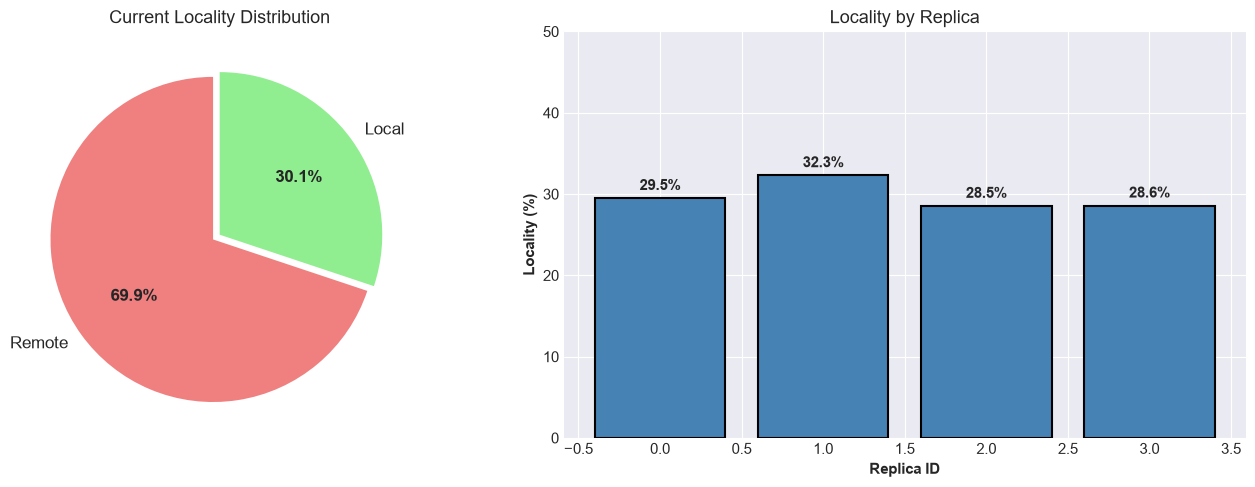

Locality Statistics:
  - Global rate: 30.1%
  - Local placements: 898
  - Remote placements: 2,083
  - Target objective: 70-80%


In [7]:
# ============================================
# 5. CURRENT LOCALITY ANALYSIS
# ============================================

def plot_locality_analysis(placements_df: pd.DataFrame) -> None:
    """
    Visualize the current state of data locality.
    
    This function creates:
    1. A pie chart showing local vs. remote proportion
    2. A bar chart showing locality by replica
    
    Args:
        placements_df (pd.DataFrame): DataFrame containing placement data.
    """
    # Create a figure with two side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Subplot 1: Pie chart ---
    # Count local vs. remote placements
    locality_counts = placements_df['is_local'].value_counts()
    
    # Create pie chart
    wedges, texts, autotexts = axes[0].pie(
        locality_counts,
        labels=['Remote', 'Local'],
        autopct='%1.1f%%',
        colors=['lightcoral', 'lightgreen'],
        startangle=90,
        explode=[0.05, 0],
        textprops={'fontsize': 12}
    )
    
    # Highlight percentage labels
    for autotext in autotexts:
        autotext.set_fontweight('bold')
    
    axes[0].set_title('Current Locality Distribution', fontsize=13)
    
    # --- Subplot 2: Locality by replica ---
    # Calculate locality percentage for each replica
    locality_by_replica = placements_df.groupby('replica_id')['is_local'].mean() * 100
    
    # Create bar chart
    bars = axes[1].bar(
        locality_by_replica.index,
        locality_by_replica.values,
        color='steelblue',
        edgecolor='black',
        linewidth=1.5
    )
    
    # Add value labels on bars
    for bar, value in zip(bars, locality_by_replica.values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{value:.1f}%', ha='center', fontweight='bold')
    
    axes[1].set_xlabel('Replica ID', fontweight='bold')
    axes[1].set_ylabel('Locality (%)', fontweight='bold')
    axes[1].set_title('Locality by Replica', fontsize=13)
    axes[1].set_ylim(0, 50)
    
    plt.tight_layout()
    plt.show()
    
    # Display statistics
    global_locality = placements_df['is_local'].mean() * 100
    print("Locality Statistics:")
    print(f"  - Global rate: {global_locality:.1f}%")
    print(f"  - Local placements: {placements_df['is_local'].sum():,}")
    print(f"  - Remote placements: {(~placements_df['is_local']).sum():,}")
    print(f"  - Target objective: 70-80%")


# Execute the visualization
plot_locality_analysis(placements)

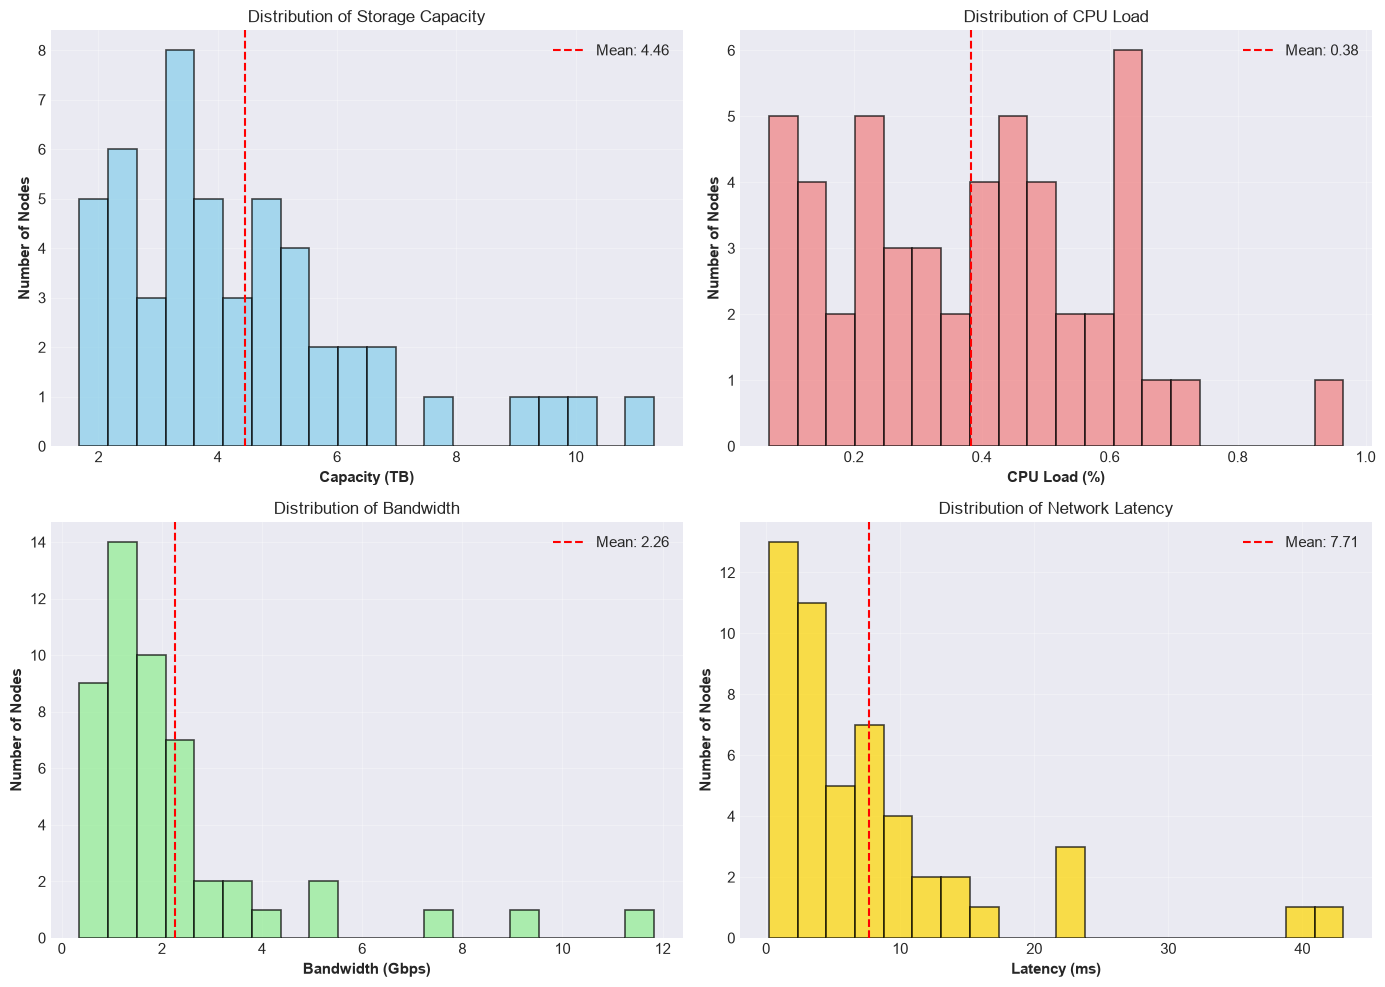

: 

In [ ]:
# ============================================
# 6. DATANODE CHARACTERISTICS ANALYSIS
# ============================================

def plot_datanode_characteristics(datanodes_df: pd.DataFrame) -> None:
    """
    Visualize the main characteristics of DataNodes.
    
    Creates a 2x2 grid of plots showing:
    1. Storage capacity distribution
    2. CPU load distribution
    3. Bandwidth distribution
    4. Network latency distribution
    
    Args:
        datanodes_df (pd.DataFrame): DataFrame containing DataNode data.
    """
    # Create a figure with 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Define characteristics to visualize
    characteristics = [
        {
            'data': datanodes_df['capacity_tb'],
            'title': 'Storage Capacity',
            'xlabel': 'Capacity (TB)',
            'color': 'skyblue'
        },
        {
            'data': datanodes_df['cpu_usage'],
            'title': 'CPU Load',
            'xlabel': 'CPU Load (%)',
            'color': 'lightcoral'
        },
        {
            'data': datanodes_df['bandwidth_gbps'],
            'title': 'Bandwidth',
            'xlabel': 'Bandwidth (Gbps)',
            'color': 'lightgreen'
        },
        {
            'data': datanodes_df['network_latency_ms'],
            'title': 'Network Latency',
            'xlabel': 'Latency (ms)',
            'color': 'gold'
        }
    ]
    
    # Loop through characteristics and create plots
    for idx, char in enumerate(characteristics):
        # Determine position in the grid
        row = idx // 2
        col = idx % 2
        
        # Create histogram
        axes[row, col].hist(
            char['data'],
            bins=20,
            color=char['color'],
            edgecolor='black',
            alpha=0.7,
            linewidth=1.2
        )
        
        # Configure labels
        axes[row, col].set_xlabel(char['xlabel'], fontweight='bold')
        axes[row, col].set_ylabel('Number of Nodes', fontweight='bold')
        axes[row, col].set_title(f"Distribution of {char['title']}", fontsize=12)
        
        # Add grid
        axes[row, col].grid(True, alpha=0.3)
        
        # Add mean as reference line
        mean_value = char['data'].mean()
        axes[row, col].axvline(mean_value, color='red', linestyle='--', 
                               linewidth=1.5, label=f'Mean: {mean_value:.2f}')
        axes[row, col].legend()
    
    # Adjust spacing
    plt.tight_layout()
    plt.show()


# Execute the visualization
plot_datanode_characteristics(datanodes)